In [2]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


In [2]:
!pip install evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 24.6 MB/s  0:00:00m0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 37.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.5/567.5 kB 23.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 35.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 33.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28/28 [evidently]28 [evidently]s]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
!pip uninstall evidently -y
!pip install evidently==0.4.19


Found existing installation: evidently 0.4.19
Uninstalling evidently-0.4.19:
  Successfully uninstalled evidently-0.4.19
  Using cached evidently-0.4.19-py3-none-any.whl.metadata (12 kB)
Using cached evidently-0.4.19-py3-none-any.whl (3.4 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
!pip uninstall numpy -y
!pip install numpy==1.26.4


Found existing installation: numpy 2.4.1
Uninstalling numpy-2.4.1:
  Successfully uninstalled numpy-2.4.1
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip uninstall numpy -y
!pip install numpy==1.26.4


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import requests
import datetime
import pandas as pd

from evidently.pipeline.column_mapping import ColumnMapping
from evidently.report import Report
from evidently.metrics import (
    ColumnMetric,
    DatasetDriftMetric,
    DatasetMissingValuesMetric,
    DatasetSummaryMetric,
    RegressionErrorMetric
)

from joblib import load, dump
from tqdm import tqdm
from sklearn.linear_model import LinearRegression


In [9]:
import requests
from pathlib import Path

urls = [
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet",
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet"
]

save_dir = Path("/workspaces/MLops/01")
save_dir.mkdir(parents=True, exist_ok=True)

for url in urls:
    file_name = url.split("/")[-1]
    save_path = save_dir / file_name

    print(f"Downloading {file_name}...")

    r = requests.get(url, stream=True)
    r.raise_for_status()

    with open(save_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print(f"Saved to {save_path}\n")


Saved to /workspaces/MLops/01/green_tripdata_2021-01.parquet

Saved to /workspaces/MLops/01/green_tripdata_2021-02.parquet



In [10]:
jan_data=pd.read_parquet("/workspaces/MLops/01/green_tripdata_2021-01.parquet")


In [11]:
jan_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,76518.000000,76518,76518,40471.000000,76518.000000,76518.000000,40471.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,40471.000000,40471.000000,40471.000000
mean,1.905290,2021-01-16 15:52:22.173018,2021-01-16 16:12:17.846781,1.143041,109.590371,130.685577,1.192311,40.862552,19.939777,0.740462,0.254104,1.506499,0.546209,0.298142,23.574820,1.406958,1.030590,0.613828
min,1.000000,2009-01-01 00:03:25,2009-01-01 00:12:25,1.000000,1.000000,1.000000,0.000000,0.000000,-280.000000,-5.500000,-0.500000,-9.450000,0.000000,-0.300000,-280.300000,1.000000,1.000000,0.000000
25%,2.000000,2021-01-08 23:22:00,2021-01-08 23:42:32,1.000000,55.000000,65.000000,1.000000,1.300000,9.000000,0.000000,0.000000,0.000000,0.000000,0.300000,11.800000,1.000000,1.000000,0.000000
50%,2.000000,2021-01-16 10:11:45,2021-01-16 10:30:42.500000,1.000000,76.000000,129.000000,1.000000,2.590000,16.730000,0.000000,0.500000,1.160000,0.000000,0.300000,20.640000,1.000000,1.000000,0.000000
75%,2.000000,2021-01-24 09:41:04.250000,2021-01-24 09:55:45,1.000000,166.000000,197.000000,1.000000,5.760000,25.500000,1.000000,0.500000,2.750000,0.000000,0.300000,29.320000,2.000000,1.000000,0.000000
max,2.000000,2021-01-31 23:46:45,2021-02-01 16:56:37,99.000000,265.000000,265.000000,8.000000,244152.010000,284.000000,8.250000,0.500000,110.000000,31.250000,0.300000,294.510000,5.000000,2.000000,2.750000
std,0.292816,NaN,NaN,0.878693,71.063053,77.101641,0.756395,1924.408778,14.984241,1.184429,0.251467,1.877930,1.876162,0.029243,16.361991,0.517005,0.172206,1.145076


In [12]:
jan_data['duration_min']=jan_data.lpep_dropoff_datetime-jan_data.lpep_pickup_datetime
jan_data['duration_min']=jan_data.duration_min.apply(lambda x: x.total_seconds()/60)

In [15]:
jan_data=jan_data[(jan_data.duration_min>=0)& (jan_data.duration_min<=60)]
jan_data=jan_data[(jan_data.passenger_count>=0)& (jan_data.passenger_count<=6)]

<Axes: >

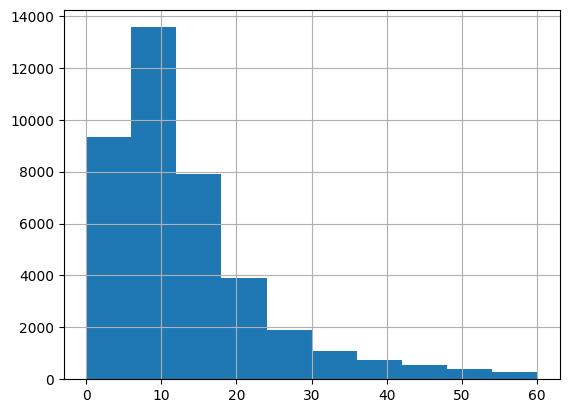

In [16]:
jan_data.duration_min.hist()

In [17]:
target="duration_min"
num_features=["passenger_count","trip_distance","fare_amount","extra","mta_tax","tip_amount","tolls_amount","improvement_surcharge"]

cat_features=["PULocationID","DOLocationID"]

In [19]:
train_data=jan_data.sample(frac=0.8, random_state=42)
val_data=jan_data.drop(train_data.index)

In [20]:
model=LinearRegression() 
model.fit(train_data[num_features+cat_features], train_data[target])
train_preds=model.predict(train_data[num_features + cat_features])
train_data['prediction']=train_preds

val_preds=model.predict(val_data[num_features + cat_features])
val_data['prediction']=val_preds


In [21]:
print(mean_absolute_error(train_data[target], train_data['prediction']))
print(mean_absolute_percentage_error(train_data[target], train_data['prediction']))

3.828566296198302
42656261862336.71


### dump model and refernece data

In [22]:
with open('/workspaces/MLops/01/models/lin_reg.bin','wb') as f_out:
    dump(model, f_out)

In [30]:
val_data.to_parquet('/workspaces/MLops/01/data/reference.parquet')
  

### Report

In [ ]:
column_mapping=ColumnMapping(
    target=None,
    prediction='prediction',
    numerical_feaatures=num_features,
    categorical_features=num_features,
    categorcal_features=cat_features
)

In [ ]:
report=Report(metrics=[
    ColumnDriftMetric(column_name='prediction'),
    DatasetDriftMetric(),
    DatasetMissingValuesMetric(),
])

In [ ]:
report.run(reference_data=train_data, current_data=val_data, column_mapping=column_mapping)
report.show(mode='inline')

In [ ]:
result=report.as_dict()
result

In [ ]:
#preediction drift
result['metrics'][0]['result']['drift_score']

In [ ]:
#share of missing values

result['metrics'][1]['result']['current']